In [13]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [14]:


DATA_DIR = Path("json_data")


def load_json_file(path: Path) -> list[dict]:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"JSON file not found: {path}")

    text = path.read_text(encoding="utf-8")
    payload = json.loads(text)
    if not isinstance(payload, list):
        raise ValueError(f"Expected a JSON array in {path}, got {type(payload).__name__}")

    records: list[dict] = []
    benchmark = path.stem
    for entry in payload:
        if not isinstance(entry, dict):
            continue
        row = entry.copy()
        row["source_file"] = path.name
        row["benchmark"] = benchmark
        if "columns" in row and "rows" in row:
            row["cells"] = int(row.get("columns", 0)) * int(row.get("rows", 0))
            row["aspect_ratio"] = row["columns"] / row["rows"] if row["rows"] else np.nan
        records.append(row)
    return records


def load_json_data(path: Path) -> pd.DataFrame:
    path = Path(path)
    records: list[dict] = []
    if path.is_dir():
        for file in sorted(path.glob("*.json")):
            records.extend(load_json_file(file))
    else:
        records.extend(load_json_file(path))
    return pd.DataFrame(records)


df = load_json_data(DATA_DIR)
print("Loaded df:", df.shape)

Loaded df: (2280, 24)


In [15]:
df


,columns,rows,seed,microseconds,all_pairs_connected,branch_ratio,steps_count,memory_peak_bytes,wall_density,dead_end_count,...,diameter,longest_path,symmetry_score,fractal_dimension,aspl,entropy,source_file,benchmark,cells,aspect_ratio
0,100,50,101,50,True,0.243800,5000,5400,0.500100,1221,...,240,240,0.510200,1.804253,109.814454,7.493328,binary_tree.json,binary_tree,5000,2.0
1,100,50,202,62,True,0.251800,5000,5400,0.500100,1261,...,256,256,0.518733,1.804253,112.381194,7.545034,binary_tree.json,binary_tree,5000,2.0
2,100,50,303,61,True,0.245400,5000,5400,0.500100,1229,...,233,233,0.512933,1.804253,108.869091,7.442613,binary_tree.json,binary_tree,5000,2.0
3,100,50,404,60,True,0.251400,5000,5400,0.500100,1259,...,258,258,0.506733,1.804253,110.879759,7.522766,binary_tree.json,binary_tree,5000,2.0
4,100,50,505,61,True,0.251400,5000,5400,0.500100,1259,...,254,254,0.511933,1.804253,114.148935,7.575597,binary_tree.json,binary_tree,5000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2275,72,40,606,12602,True,0.260069,3593463,17920,0.500174,835,...,467,467,0.517940,1.720581,165.953472,8.602992,watson.json,watson,2880,1.8
2276,72,40,707,12802,True,0.254861,3625539,17920,0.500174,840,...,341,341,0.503704,1.720581,128.386130,8.122559,watson.json,watson,2880,1.8
2277,72,40,808,13027,True,0.265972,3672536,17920,0.500174,865,...,276,276,0.520486,1.720581,106.290922,7.771808,watson.json,watson,2880,1.8
2278,72,40,909,13427,True,0.256250,3561382,17920,0.500174,840,...,330,330,0.518056,1.720581,128.884828,8.109860,watson.json,watson,2880,1.8


In [16]:
new_df = df.drop(['columns','rows','seed','all_pairs_connected','source_file','cycle_count',\
                  'memory_peak_bytes','benchmark','microseconds','longest_path'], axis=1).dropna()
new_df

,branch_ratio,steps_count,wall_density,dead_end_count,dead_end_ratio,corridor_ratio,avg_degree,diameter,symmetry_score,fractal_dimension,aspl,entropy,cells,aspect_ratio
0,0.243800,5000,0.500100,1221,0.244200,0.512000,1.999600,240,0.510200,1.804253,109.814454,7.493328,5000,2.0
1,0.251800,5000,0.500100,1261,0.252200,0.496000,1.999600,256,0.518733,1.804253,112.381194,7.545034,5000,2.0
2,0.245400,5000,0.500100,1229,0.245800,0.508800,1.999600,233,0.512933,1.804253,108.869091,7.442613,5000,2.0
3,0.251400,5000,0.500100,1259,0.251800,0.496800,1.999600,258,0.506733,1.804253,110.879759,7.522766,5000,2.0
4,0.251400,5000,0.500100,1259,0.251800,0.496800,1.999600,254,0.511933,1.804253,114.148935,7.575597,5000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2275,0.260069,3593463,0.500174,835,0.289931,0.450000,1.999306,467,0.517940,1.720581,165.953472,8.602992,2880,1.8
2276,0.254861,3625539,0.500174,840,0.291667,0.453472,1.999306,341,0.503704,1.720581,128.386130,8.122559,2880,1.8
2277,0.265972,3672536,0.500174,865,0.300347,0.433681,1.999306,276,0.520486,1.720581,106.290922,7.771808,2880,1.8
2278,0.256250,3561382,0.500174,840,0.291667,0.452083,1.999306,330,0.518056,1.720581,128.884828,8.109860,2880,1.8


In [17]:
new_df.columns

Index(['branch_ratio', 'steps_count', 'wall_density', 'dead_end_count',
       'dead_end_ratio', 'corridor_ratio', 'avg_degree', 'diameter',
       'symmetry_score', 'fractal_dimension', 'aspl', 'entropy', 'cells',
       'aspect_ratio'],
      dtype='str')

In [18]:
scaler = StandardScaler()
new_df_scaled = scaler.fit_transform(new_df)
print(f"Подготовлено данных: {new_df_scaled.shape[0]} объектов, {new_df_scaled.shape[1]} признаков.")


Подготовлено данных: 2280 объектов, 14 признаков.


In [19]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(new_df_scaled)
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['benchmark'] = df['benchmark'].values  # Раскрашивать будем по алгоритму


In [20]:
print(f"Объясненная дисперсия: PC1 = {pca.explained_variance_ratio_[0]:.2%}, PC2 = {pca.explained_variance_ratio_[1]:.2%}")
print(f"Суммарно: {sum(pca.explained_variance_ratio_):.2%}")

Объясненная дисперсия: PC1 = 42.44%, PC2 = 27.50%
Суммарно: 69.94%


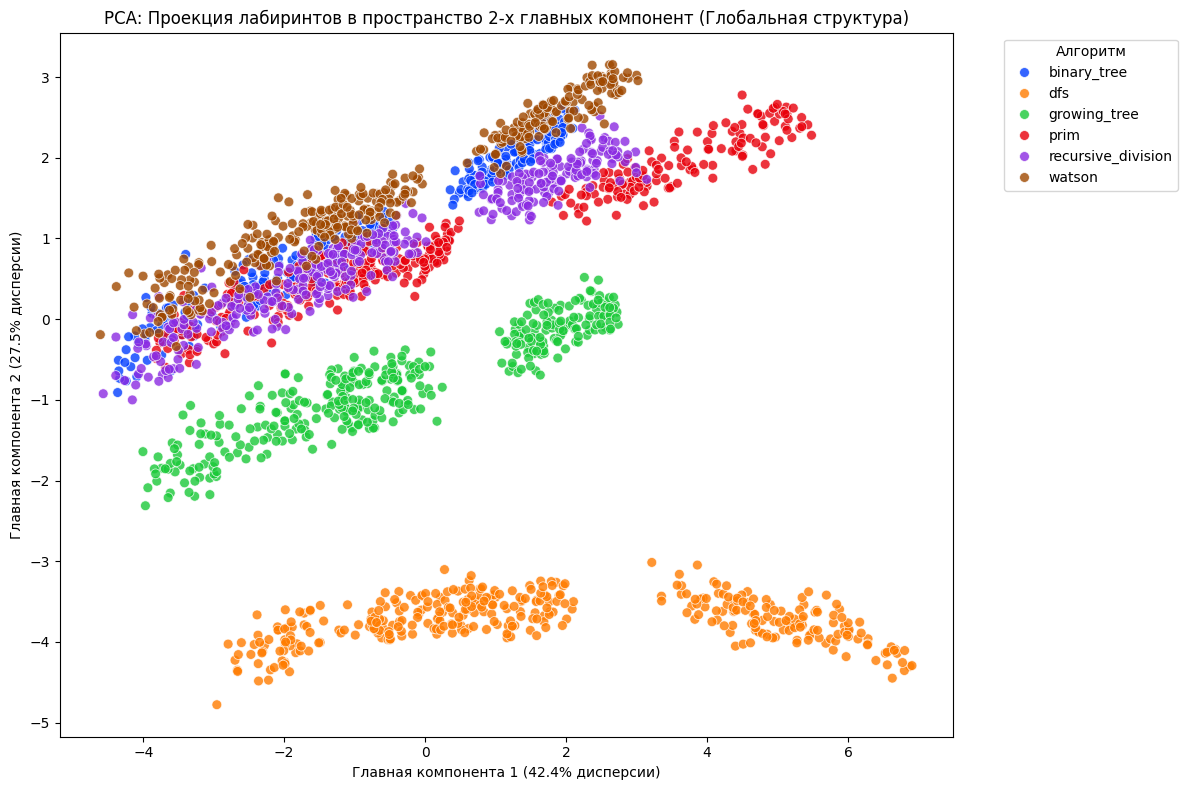

In [25]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='benchmark', palette='bright', s=50, alpha=0.8)
plt.title('PCA: Проекция лабиринтов в пространство 2-х главных компонент (Глобальная структура)')
plt.xlabel(f'Главная компонента 1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)')
plt.ylabel(f'Главная компонента 2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Алгоритм')
plt.tight_layout()
plt.show()

In [22]:
pc_weights = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=new_df.columns
)

print("\nИнтерпретация главных компонент (веса признаков):")
# Сортируем признаки для PC1 по абсолютному вкладу
print("\n--- Ведущие признаки для PC1 ---")
print(pc_weights['PC1'].abs().sort_values(ascending=False).head(5))
print("\n--- Ведущие признаки для PC2 ---")
print(pc_weights['PC2'].abs().sort_values(ascending=False).head(5))


Интерпретация главных компонент (веса признаков):

--- Ведущие признаки для PC1 ---
cells           0.358995
entropy         0.355482
wall_density    0.347155
avg_degree      0.347086
aspl            0.331209
Name: PC1, dtype: float64

--- Ведущие признаки для PC2 ---
branch_ratio      0.467875
corridor_ratio    0.466749
dead_end_ratio    0.462826
dead_end_count    0.323602
diameter          0.206184
Name: PC2, dtype: float64


### Промежуточный вывод
на графике явно видно, что у dfs огромные проблемы с ветвистостью, количеством тупиков, коридорностью.
Доминирующим по ветвисти является алгоритм ватсона,
По данным PC1(степень блокировок путей, возможности пойти в другую клетку) доминирующим является dfs, по PC2(степень ветвистости и выбора) является watson. Алгоритмы Watson, binary, prim, req_division являются очень схожими, хоть и отличимыми. Самым средним по показательям оказался алгоритм выращивания дерева.

# ПУНКТ 2

Composite Indicator (композитный индикатор) или индекс